In [1]:
import pandas as pd
df = pd.read_csv("../data/train.csv")

print(df.shape) # shape:看資料表的 大小（幾列幾欄）

(42000, 785)


In [2]:
df.head() # head:顯示前幾列資料（預設前 5 列）

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.info() #info:顯示整個 DataFrame 的摘要資訊

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# 取出第一筆資料
label = df.iloc[0,0] # label:正確答案  iloc:依照位置(index position)取資料
pixels = df.iloc[0, 1:].values # pixel:784個像素值   values:把Pandas的Series轉成numpy array

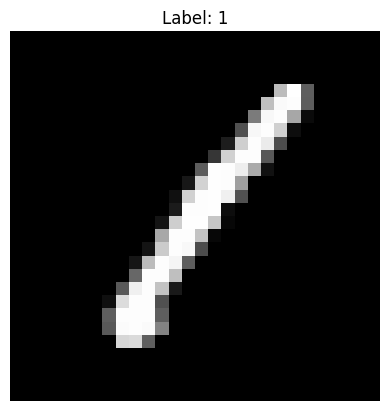

In [6]:
# 轉成圖片並顯示
img = pixels.reshape(28, 28)

plt.imshow(img, cmap="gray") # imshow:顯示影像   cmap="gray":灰階模式
plt.title(f"Label: {label}") # f:格式化字串，指這個字串可以在{}內插入變數
plt.axis("off") # 把座標軸關掉
plt.show()

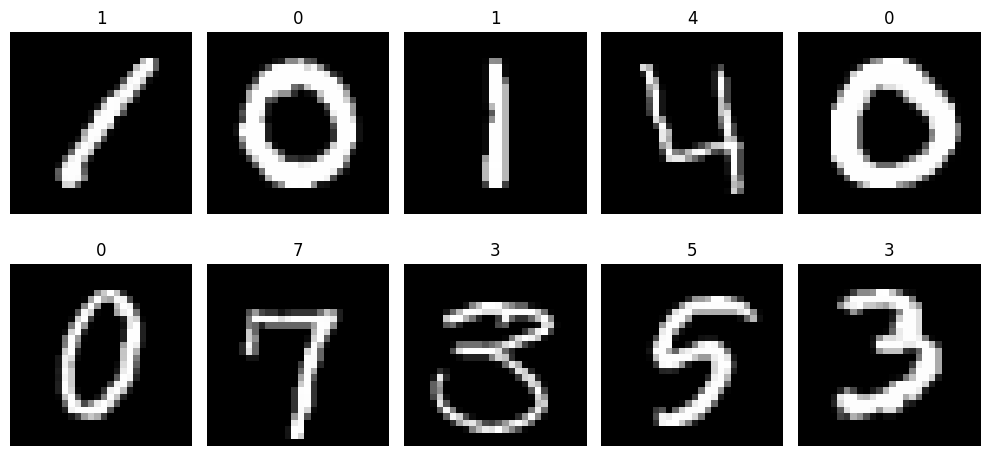

In [7]:
# 繪製前10張圖
fig, axes = plt.subplots(2,5, figsize=(10,5)) 
# fig:整個畫布
# axes:每一格小圖
# plt.subplots(2,5) 建立2*5的array
# figsize=(10,5) :整體圖大小

for i, ax in enumerate(axes.flat):
    # axes.flat：把 2×5 的矩陣「攤平成 1D」
    # enumerate： i = 第幾張圖（0~9）、 ax = 對應的 subplot
    label = df.iloc[i,0]
    img = df.iloc[i,1:].values.reshape(28,28)
    
    ax.imshow(img, cmap="gray")
    ax.set_title(label) # set_title:設定某一張子圖的標題
    ax.axis("off")

plt.tight_layout() # 自動調整子圖間距，避免重疊
plt.show()

In [9]:
# 準備 x / y
x_raw = df.drop("label", axis=1) 
y = df["label"]
# drop(被丟掉的東西, axis=1代表往行的方向)

print(x_raw.shape) # X:影像（特徵）
print(y.shape) # y:正確答案（label）

(42000, 784)
(42000,)


In [10]:
# 切資料
from sklearn.model_selection import train_test_split # 引入切資料工具

x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x_raw, y,
    test_size=0.2,
    random_state=42 # 固定亂數，確保每次切出來都一樣
) # 20% 當 test set、80% 當 training set

In [11]:
# 確認資料大小
print(x_train_raw.shape)
print(x_test_raw.shape)
print(y_train.shape)
print(y_test.shape)

(33600, 784)
(8400, 784)
(33600,)
(8400,)


In [12]:
# Logistic Regression
# 匯入模型
from sklearn.linear_model import LogisticRegression

In [13]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # 建立 scaler
x_train_scaled = scaler.fit_transform(x_train_raw)
x_test_scaled = scaler.transform(x_test_raw)

In [14]:
# PCA
from sklearn.decomposition import PCA # 用PCA降維

pca = PCA(n_components=0.95) # 保留95%的variance

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [15]:
# Model
model = LogisticRegression(
    solver="lbfgs", # saga:專門用於高維資料
    max_iter = 2000, # max_iter:訓練最大迭代次數
    n_jobs = -1 # 全用CPU跑
) 

In [16]:
# 開始訓練
model.fit(x_train_pca, y_train)
print("training done")

training done


In [17]:
# Prediction
y_pred_lr = model.predict(x_test_pca)

In [18]:
# Accuracy
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", acc)

Accuracy: 0.9163095238095238


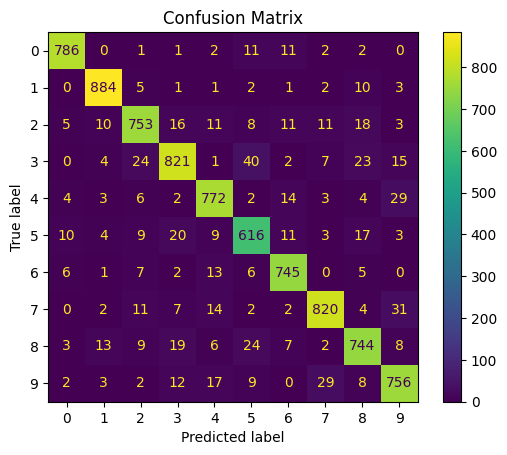

In [19]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr) # 計算 confusion matrix

plt.title("Confusion Matrix")
plt.show()

In [20]:
# CNN
# Normalize
x_train_cnn = x_train_raw / 255.0
x_test_cnn = x_test_raw / 255.0

In [21]:
# reshape
x_train_cnn = x_train_cnn.values.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_cnn.values.reshape(-1, 28, 28, 1)
# 1:grayscale
# -1:自動batch size

In [22]:
# Model
import tensorflow as tf
from tensorflow.keras import layers, models

model_cnn = models.Sequential([

    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [23]:
# Compile
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# training
history = model_cnn.fit(
    x_train_cnn, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9022 - loss: 0.3362 - val_accuracy: 0.9659 - val_loss: 0.1153
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9743 - loss: 0.0848 - val_accuracy: 0.9769 - val_loss: 0.0732
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9814 - loss: 0.0583 - val_accuracy: 0.9753 - val_loss: 0.0795
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9858 - loss: 0.0436 - val_accuracy: 0.9805 - val_loss: 0.0598
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9896 - loss: 0.0330 - val_accuracy: 0.9826 - val_loss: 0.0559


In [25]:
# Predict
y_pred_cnn = model_cnn.predict(x_test_cnn)
y_pred_cnn = y_pred_cnn.argmax(axis=1)


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [26]:
# Accuracy
from sklearn.metrics import accuracy_score

cnn_acc = accuracy_score(y_test, y_pred_cnn)

print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.9838095238095238


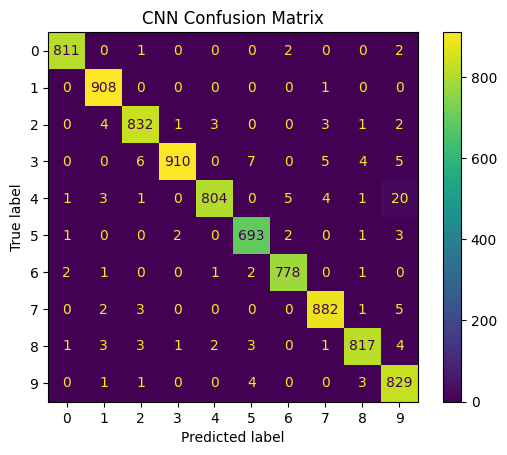

In [27]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cnn
)

plt.title("CNN Confusion Matrix")
plt.show()

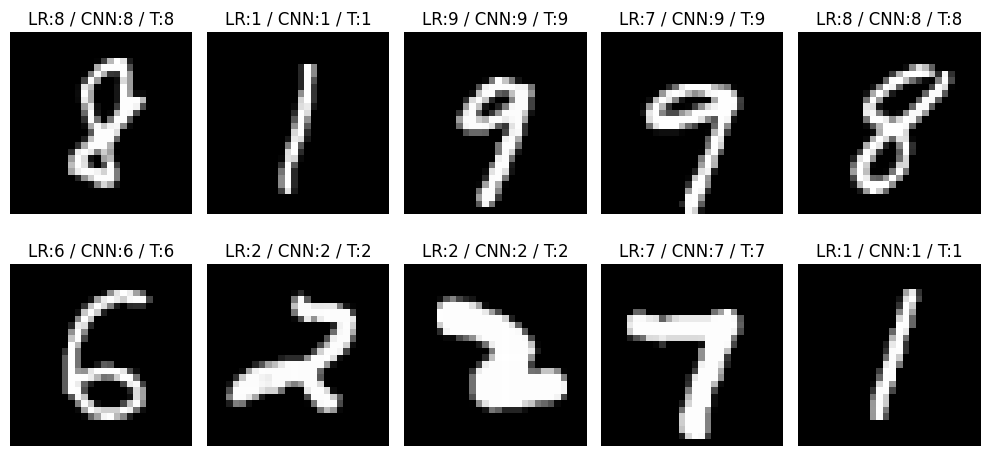

In [28]:
# 實際預測結果，從test data裡拿前10張圖繪製
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = x_test_raw.iloc[i].values.reshape(28, 28)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"LR:{y_pred_lr[i]} / CNN:{y_pred_cnn[i]} / T:{y_test.iloc[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()